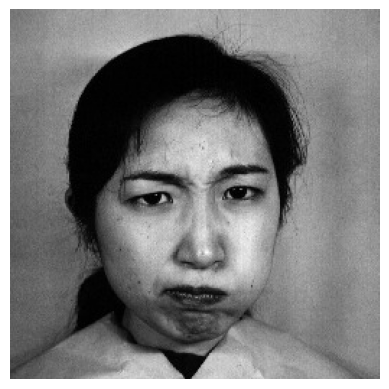

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mimg

user_id = 'ANGRY'
sample_id = 'angry2.jpg'

path = "C:\\Users\\DELL\\Downloads\\real\\jaffe\\%s\\%s" % (user_id, sample_id)

im = mimg.imread(path)
plt.imshow(im, cmap='gray')
plt.axis('off')
plt.show()


In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


Define Functions to Load and Preprocess Data

In [3]:
def load_images_from_folder(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
            labels.append(label)
    return images, labels

def load_jaffe_dataset(base_path):
    emotions = ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'SAD', 'SURPRISE']
    all_images = []
    all_labels = []
    for emotion in emotions:
        folder_path = os.path.join(base_path, emotion)
        images, labels = load_images_from_folder(folder_path, emotion)
        all_images.extend(images)
        all_labels.extend(labels)
    return np.array(all_images), np.array(all_labels)

def preprocess_images(images, labels):
    images = np.array([cv2.resize(img, (48, 48)) for img in images])
    images = images / 255.0
    images = images.reshape(-1, 48, 48, 1)  # Adding channel dimension
    le = LabelEncoder()
    labels = le.fit_transform(labels)
    labels = to_categorical(labels)
    return images, labels, le


Load and Preprocess the Data

In [4]:
base_path = 'C:\\Users\\DELL\\Downloads\\real\\jaffe'
images, labels = load_jaffe_dataset(base_path)
images, labels, label_encoder = preprocess_images(images, labels)


Split the Data into Training and Testing Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=4)

Define the CNN Architecture

In [6]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),  # Dropout layer to reduce overfitting
        Dense(num_classes, activation='softmax')  # Output layer with num_classes units
    ])

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


Build and Compile the Model

In [7]:
model = build_cnn_model((48, 48, 1), num_classes=len(label_encoder.classes_))

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the CNN Model

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=2
)


Epoch 1/150
5/5 - 3s - 521ms/step - accuracy: 0.1712 - loss: 1.8031 - val_accuracy: 0.1081 - val_loss: 1.8126
Epoch 2/150
5/5 - 0s - 46ms/step - accuracy: 0.1918 - loss: 1.7899 - val_accuracy: 0.1081 - val_loss: 1.8120
Epoch 3/150
5/5 - 0s - 49ms/step - accuracy: 0.1781 - loss: 1.7963 - val_accuracy: 0.1081 - val_loss: 1.8105
Epoch 4/150
5/5 - 0s - 44ms/step - accuracy: 0.1575 - loss: 1.7934 - val_accuracy: 0.1351 - val_loss: 1.7997
Epoch 5/150
5/5 - 0s - 46ms/step - accuracy: 0.1438 - loss: 1.7875 - val_accuracy: 0.1351 - val_loss: 1.7989
Epoch 6/150
5/5 - 0s - 47ms/step - accuracy: 0.2603 - loss: 1.7715 - val_accuracy: 0.1351 - val_loss: 1.7992
Epoch 7/150
5/5 - 0s - 46ms/step - accuracy: 0.2055 - loss: 1.7851 - val_accuracy: 0.1081 - val_loss: 1.8011
Epoch 8/150
5/5 - 0s - 46ms/step - accuracy: 0.2192 - loss: 1.7741 - val_accuracy: 0.1081 - val_loss: 1.8037
Epoch 9/150
5/5 - 0s - 47ms/step - accuracy: 0.2534 - loss: 1.7643 - val_accuracy: 0.1622 - val_loss: 1.7989
Epoch 10/150
5/5 -

Evaluate the Model Performance

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8378 - loss: 0.8495
Test accuracy: 0.8378


Save the Model

In [10]:
model.save('emotion_detection_cnn_model.h5')


Load the Model

In [11]:
from tensorflow.keras.models import load_model

model = load_model('emotion_detection_cnn_model.h5')

Define a Function to Predict Emotions

In [12]:

def predict_emotion(image_path, model, label_encoder):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0
    img_reshaped = img_normalized.reshape(1, 48, 48, 1)  # Adding channel dimension
    prediction = model.predict(img_reshaped)
    emotion = label_encoder.inverse_transform([np.argmax(prediction)])
    return emotion[0]  # Return the emotion and the resized image


Test the Prediction Function

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
Predicted emotion: ANGRY
ANGRY


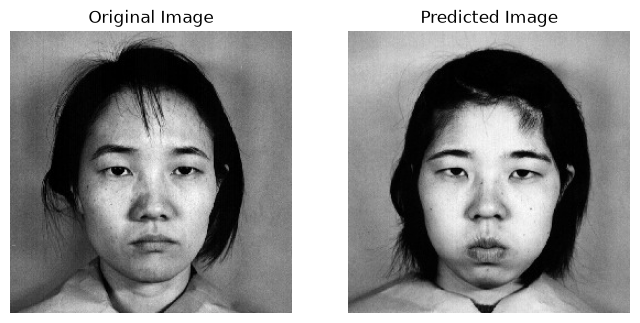

In [16]:
user_id = 'ANGRY'
sample_id = 'angry26.jpg'

path1 = "C:\\Users\\DELL\\Downloads\\real\\jaffe\\%s\\%s" % (user_id, sample_id)


emotion = predict_emotion(path1, model, label_encoder)
predic = f"C:\\Users\\DELL\\Downloads\\real\\jaffe\\{emotion}\\{emotion.lower()}7.jpg"
prd = mimg.imread(predic)

print(f"Predicted emotion: {emotion}")
print(emotion)
imorig = mimg.imread(path1)
plt.figure(1,(8,5))
plt.subplot(1,2,1)
plt.imshow(imorig,cmap='gray')
plt.axis('off')
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(prd,cmap='gray')
plt.axis('off')
plt.title("Predicted Image")
plt.show()

Plot Training and Validation Metrics

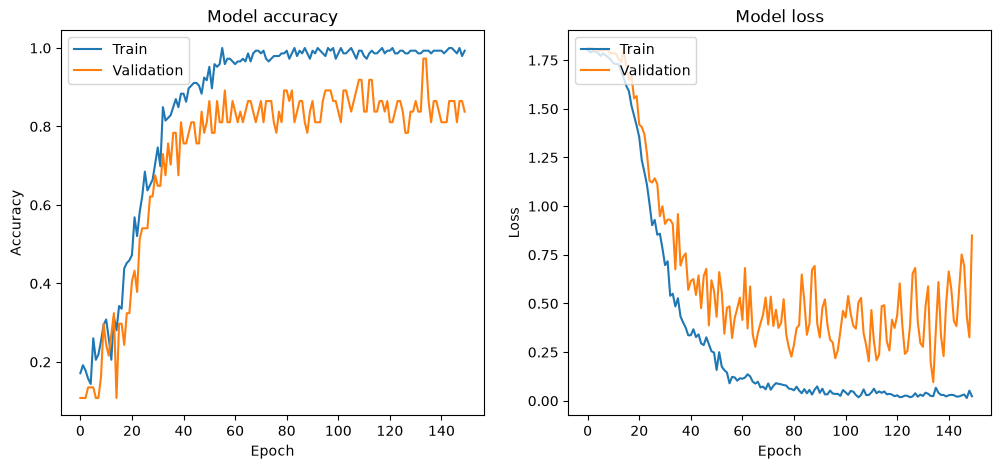

In [17]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

# Plot the training history
plot_training_history(history)
